# 03 — Population analysis

**Objective.** Describe national population and demographic structure.

**Business relevance.** Establish a transparent descriptive evidence base without merging incompatible populations or implying causality.

**Data source.** Destatis tables 12411-0005 and 12411-0013  
**Period.** 2021–2025  
**Granularity.** Year, state, sex and age  
**Units.** Persons

Last updated: 2026-08-25

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df=pd.read_csv(DATA/'fact_population_state_age_sex.csv')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

Shape: (14560, 15)


,reference_date,year,state_code,sex_code,age_code_official,age_years,age_group,population_persons,unit,quality_flag,census_basis,series_break_before,source_id,input_class,denominator
0,2021-12-31,2021,1,F,ALT000,0.0,0-17,12362,Anzahl,e,Census 2011 basis,False,DESTATIS-12411-0013,official population estimate,registered resident population at year end
1,2021-12-31,2021,1,F,ALT001,1.0,0-17,12412,Anzahl,e,Census 2011 basis,False,DESTATIS-12411-0013,official population estimate,registered resident population at year end
2,2021-12-31,2021,1,F,ALT002,2.0,0-17,12509,Anzahl,e,Census 2011 basis,False,DESTATIS-12411-0013,official population estimate,registered resident population at year end
3,2021-12-31,2021,1,F,ALT003,3.0,0-17,12963,Anzahl,e,Census 2011 basis,False,DESTATIS-12411-0013,official population estimate,registered resident population at year end
4,2021-12-31,2021,1,F,ALT004,4.0,0-17,13116,Anzahl,e,Census 2011 basis,False,DESTATIS-12411-0013,official population estimate,registered resident population at year end


,dtype
reference_date,object
year,int64
state_code,int64
sex_code,object
age_code_official,object
age_years,float64
age_group,object
population_persons,int64
unit,object
quality_flag,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reference_date,14560,5,2021-12-31,2912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,14560.0,NaN,NaN,NaN,2023.0,1.414262,2021.0,2022.0,2023.0,2024.0,2025.0
state_code,14560.0,NaN,NaN,NaN,8.5,4.609931,1.0,4.75,8.5,12.25,16.0
sex_code,14560,2,F,7280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_code_official,14560,91,ALT000,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_years,14560.0,NaN,NaN,NaN,45.0,26.268753,0.0,22.0,45.0,68.0,90.0
age_group,14560,8,45-64,3200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_persons,14560.0,NaN,NaN,NaN,28630.214766,28507.186811,522.0,9274.5,17296.5,37491.5,151752.0
unit,14560,1,Anzahl,14560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_flag,14560,1,e,14560,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values: 0
Duplicate rows: 0


,year,population_persons
0,2021,83237124
1,2022,83118501
2,2023,83456045
3,2024,83577140
4,2025,83467117


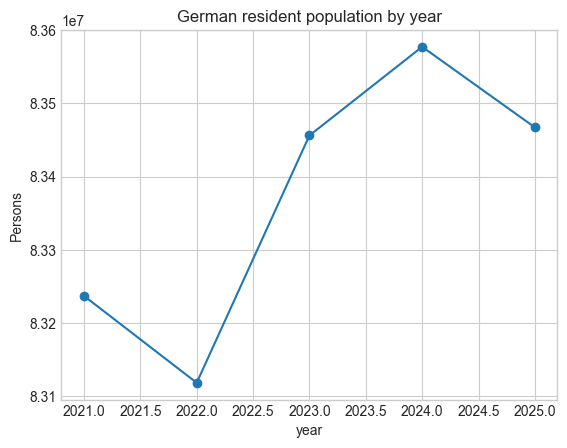

In [3]:
year=df.groupby('year',as_index=False).population_persons.sum()
display(year)
year.plot(x='year',y='population_persons',marker='o',legend=False,title='German resident population by year'); plt.ylabel('Persons'); plt.show()

,state_code,population_persons
3,4,706915
9,10,1007342
12,13,1573685
1,2,1869473
15,16,2078946
14,15,2120252
11,12,2551889
0,1,2958519
10,11,3700577
13,14,4026599


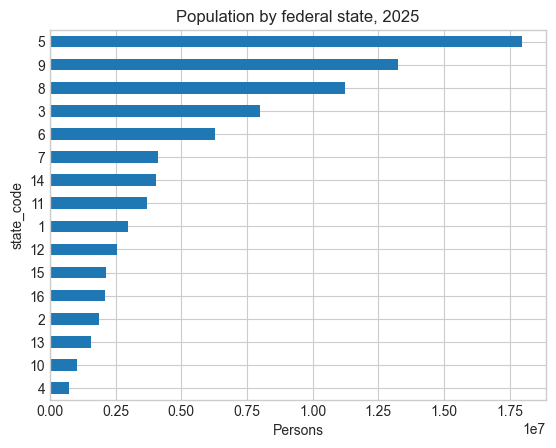

In [4]:
states=(df.query('year == 2025').groupby('state_code',as_index=False)['population_persons'].sum())
latest=states.sort_values('population_persons')
display(latest)
latest.plot.barh(x='state_code',y='population_persons',legend=False,title='Population by federal state, 2025')
plt.xlabel('Persons'); plt.show()

## Interpretation

The 2025 total is 83,467,117 residents. State and age distributions describe registered residents, not GKV membership or clinical eligibility. The 2021 series uses the Census 2011 basis; 2022 onward uses the Census 2022 basis, so the break must not be interpreted as demographic change alone.

## Limitations, outputs and conclusion

The analysis preserves source periods, units and denominators; it does not impute, interpolate or claim causality. Outputs are the displayed summary tables and Matplotlib figures. The conclusion is descriptive and should be read with the source-specific limitations above.

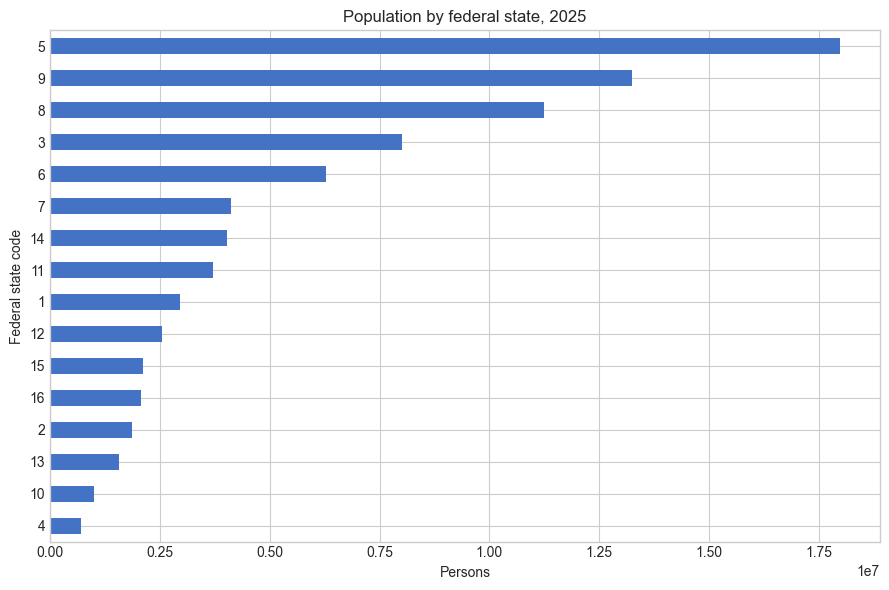

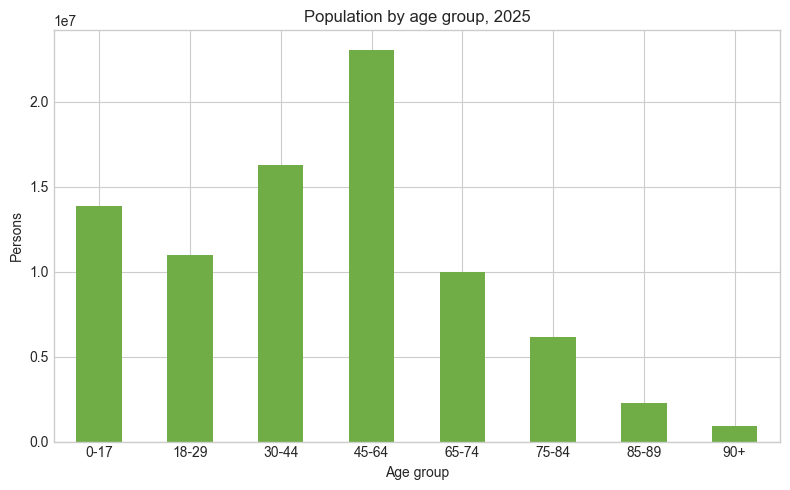

In [5]:
IMAGE_DIR = ROOT / 'images' / 'population'; IMAGE_DIR.mkdir(parents=True, exist_ok=True)
states=(df.query('year == 2025').groupby('state_code',as_index=False)['population_persons'].sum()).sort_values('population_persons')
ax=states.plot.barh(x='state_code',y='population_persons',legend=False,title='Population by federal state, 2025',figsize=(9,6),color='#4472C4')
ax.set_xlabel('Persons'); ax.set_ylabel('Federal state code'); plt.tight_layout(); plt.savefig(IMAGE_DIR/'population_by_federal_state_2025.png',dpi=180); plt.show()
ages=(df.query('year == 2025').groupby('age_group',as_index=False,sort=False)['population_persons'].sum())
ax=ages.plot.bar(x='age_group',y='population_persons',legend=False,title='Population by age group, 2025',figsize=(8,5),color='#70AD47')
ax.set_xlabel('Age group'); ax.set_ylabel('Persons'); plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(IMAGE_DIR/'population_by_age_group_2025.png',dpi=180); plt.show()
